In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
x = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
x

array([[1],
       [2],
       [3],
       [4],
       [5]])

In [3]:
y = np.array([40, 50, 50, 60, 70])
y

array([40, 50, 50, 60, 70])

In [4]:
model = LinearRegression()
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
print("Intercept : ", model.intercept_)
print("Slope : ", model.coef_[0])

Intercept :  33.0
Slope :  7.0


In [6]:
new_data = np.array([[6]])
predicted_mark = model.predict(new_data)

In [7]:
print("predicted mark : ", predicted_mark[0])

predicted mark :  75.0


In [8]:
y_pred = model.predict(x)
y_pred

array([40., 47., 54., 61., 68.])

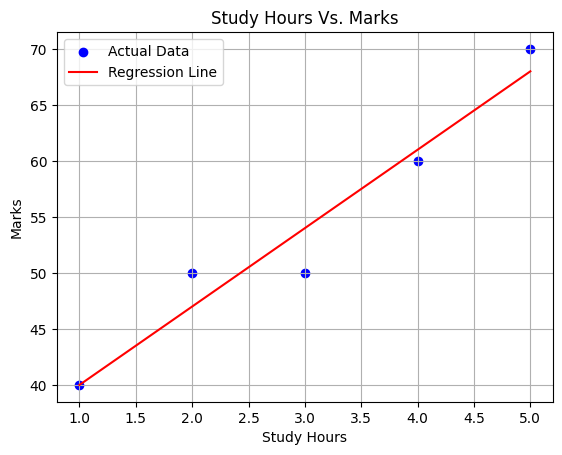

In [9]:
plt.scatter(x, y, color = "blue", label = "Actual Data")
plt.plot(x, y_pred, color = "red", label = "Regression Line")

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours Vs. Marks")
plt.grid(True)
plt.legend()
plt.show()


In [10]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [11]:
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

In [12]:
print("Mean Absolute Error : ", mae)
print("Mean Squared Error : ", mse)
print("Root Mean Squared Error : ", rmse)
print("R-squared : ", r2)

Mean Absolute Error :  2.0
Mean Squared Error :  6.0
Root Mean Squared Error :  2.449489742783178
R-squared :  0.9423076923076923


K-FOLD

In [13]:
base_x = [1, 2, 3, 4, 5]

np.random.seed(42)
expanded_x = np.random.choice(base_x, size=100, replace=True)

x = np.array(expanded_x).reshape(-1, 1)
x = x + np.random.normal(0, 0.05, x.shape) 

x[:5]


array([[3.95518324],
       [4.99440061],
       [3.07344706],
       [4.94380508],
       [5.04750027]])

In [14]:
y_mapping = {1: 40, 2: 50, 3: 50, 4: 60, 5: 70}

expanded_y = [y_mapping[int(round(val[0]))] for val in x]
y = np.array(expanded_y)

y = y + np.random.normal(0, 0.5, y.shape)

y[:5] 


array([60.40807636, 70.23585365, 49.85725535, 70.53264623, 70.42699889])

In [15]:
from sklearn.model_selection import KFold

k_values = [4, 5, 6]
test_sizes = [0.20, 0.25, 0.30]
results = []

for k in k_values:
    for test_size in test_sizes:
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42)
        
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        fold_scores = []
        
        for train_idx, val_idx in kf.split(x_train):
            x_fold_train, x_fold_val = x_train[train_idx], x_train[val_idx]
            y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
            
            fold_model = LinearRegression()
            fold_model.fit(x_fold_train, y_fold_train)
            
            y_fold_pred = fold_model.predict(x_fold_val)
            r2 = r2_score(y_fold_val, y_fold_pred)
            fold_scores.append(r2)
            
        results.append({
            "K (Folds)": k,
            "Test Size (%)": int(test_size * 100),
            "Fold Scores (R²)": [round(score, 4) for score in fold_scores],
            "Average R²": round(np.mean(fold_scores), 4)
        })


In [16]:
df_results = pd.DataFrame(results)

print("===== 9 PARAMETER COMBINATIONS RESULT =====")
df_results


===== 9 PARAMETER COMBINATIONS RESULT =====


,K (Folds),Test Size (%),Fold Scores (R²),Average R²
0,4,20,"[0.951, 0.8851, 0.9297, 0.9026]",0.9171
1,4,25,"[0.8846, 0.924, 0.9445, 0.9399]",0.9232
2,4,30,"[0.9311, 0.8531, 0.916, 0.9482]",0.9121
3,5,20,"[0.9495, 0.8943, 0.9013, 0.9412, 0.8529]",0.9078
4,5,25,"[0.9236, 0.8621, 0.9493, 0.9255, 0.9449]",0.9211
5,5,30,"[0.9103, 0.9237, 0.8519, 0.8996, 0.9628]",0.9097
6,6,20,"[0.9503, 0.9281, 0.8919, 0.8879, 0.9656, 0.808]",0.9053
7,6,25,"[0.9487, 0.7845, 0.9388, 0.9465, 0.9328, 0.9273]",0.9131
8,6,30,"[0.9151, 0.9183, 0.829, 0.8989, 0.9017, 0.9688]",0.9053


In [17]:
final_model = LinearRegression()
final_model.fit(x_train, y_train)

y_pred = final_model.predict(x_test)

print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))


MAE       :  1.766291567328562
MSE       :  4.405340591503059
RMSE      :  2.0988903238385417
R-squared :  0.9624156695608158


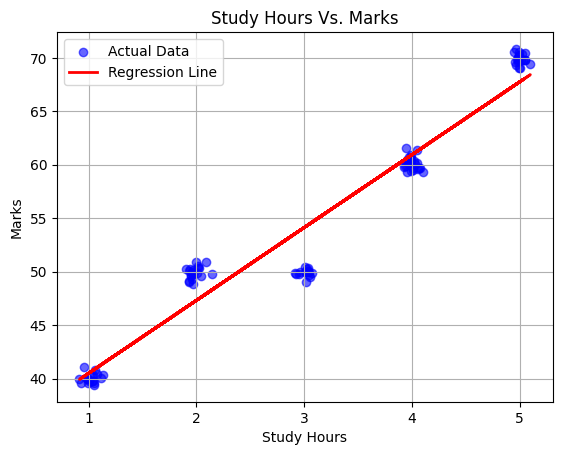

In [ ]:
y_plot_pred = final_model.predict(x)

plt.scatter(x, y, color="blue", label="Actual Data", alpha=0.6)
plt.plot(x, y_plot_pred, color="red", label="Regression Line", linewidth=2)

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours Vs. Marks")
plt.grid(True)
plt.legend()
plt.show()


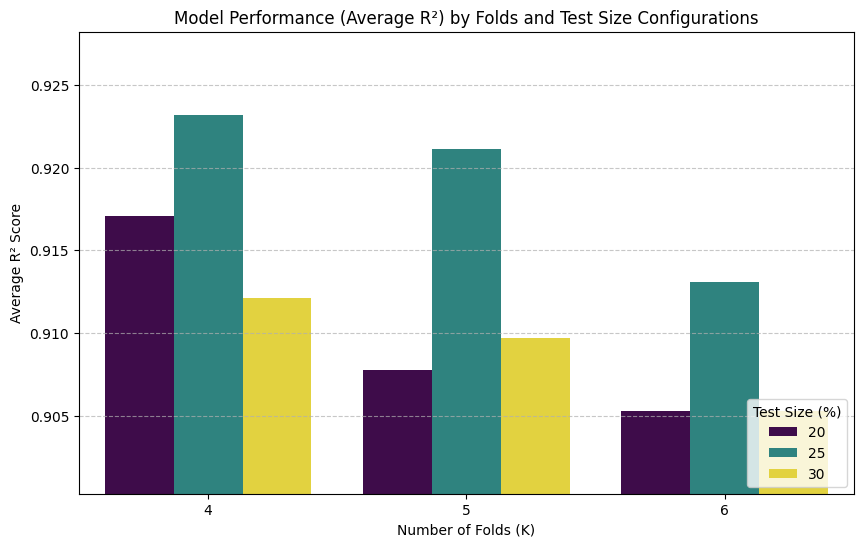

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_results, 
    x="K (Folds)", 
    y="Average R²", 
    hue="Test Size (%)", 
    palette="viridis"
)

plt.title("Model Performance (Average R²) by Folds and Test Size Configurations")
plt.xlabel("Number of Folds (K)")
plt.ylabel("Average R² Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)

min_score = df_results["Average R²"].min()
max_score = df_results["Average R²"].max()
plt.ylim(min_score - 0.005, min_score + (max_score - min_score) + 0.005)

plt.legend(title="Test Size (%)", loc="lower right")
plt.show()
